# Rainfall Weather Forecasting

## Project Description

Weather forecasting is the application of science and technology to predict the conditions of the atmosphere for a given location and time. This project uses 10 years of daily weather observations from Australia to predict:

- **Problem (a):** Whether or not it will rain tomorrow (classification)
- **Problem (b):** How much rainfall there could be

## Pipeline Order 

```
Load Data
  -> Basic Cleaning (date parsing, label encoding)
  -> Train / Test Split          <-- split FIRST
  -> EDA on raw X_train          <-- understand data before transforming it
      - distributions & class balance
      - missing value heatmap
      - correlation heatmap
      - pairplots
  -> Feature Engineering (train only)
      - MICE imputation  fit+transform(train), transform(test)
      - IQR outlier removal
      - SMOTE
      - StandardScaler  fit+transform(train), transform(test)
  -> Feature Selection (train only)
  -> Optuna Hyperparameter Tuning (CV on train)
  -> Final Evaluation on Test
  -> MLflow Logging
```

## 1. Setup & Imports

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, cohen_kappa_score,
    roc_curve, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
import optuna
import mlflow
import mlflow.sklearn

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

ModuleNotFoundError: No module named 'lightgbm'

In [13]:
!pip install lightbgm optuna mlflow

zsh:1: command not found: pip


## 2. Data Loading

In [ ]:
df = pd.read_csv('weatherAUS.csv')

df['Date']  = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df['year']  = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day']   = df['Date'].dt.day
df.drop('Date', axis=1, inplace=True)

df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,year,month,day
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12,1
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,1007.8,NaN,NaN,17.2,24.3,No,No,2008,12,2
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,1008.7,NaN,2.0,21.0,23.2,No,No,2008,12,3
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,1012.8,NaN,NaN,18.1,26.5,No,No,2008,12,4
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 25 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       145460 non-null  object 
 1   MinTemp        143975 non-null  float64
 2   MaxTemp        144199 non-null  float64
 3   Rainfall       142199 non-null  float64
 4   Evaporation    82670 non-null   float64
 5   Sunshine       75625 non-null   float64
 6   WindGustDir    135134 non-null  object 
 7   WindGustSpeed  135197 non-null  float64
 8   WindDir9am     134894 non-null  object 
 9   WindDir3pm     141232 non-null  object 
 10  WindSpeed9am   143693 non-null  float64
 11  WindSpeed3pm   142398 non-null  float64
 12  Humidity9am    142806 non-null  float64
 13  Humidity3pm    140953 non-null  float64
 14  Pressure9am    130395 non-null  float64
 15  Pressure3pm    130432 non-null  float64
 16  Cloud9am       89572 non-null   float64
 17  Cloud3pm       86102 non-null

In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,year,month,day
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000,145460.000000,145460.000000,145460.000000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339,2012.769751,6.399615,15.712258
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665,2.537684,3.427262,8.794789
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000,2007.000000,1.000000,1.000000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000,2011.000000,3.000000,8.000000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000,2013.000000,6.000000,16.000000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000,2015.000000,9.000000,23.000000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000,2017.000000,12.000000,31.000000


## 3. Basic Cleaning & Label Encoding

Only deterministic steps that do not learn any statistics from the data — safe to do before split.

In [ ]:
df['RainToday']    = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})
df.dropna(subset=['RainTomorrow'], inplace=True)

# Label-encode categorical columns
# NaN filled with mode temporarily so the encoder does not error;
# proper imputation happens after the split on train only.
cat_cols  = df.select_dtypes(include='object').columns.tolist()
lencoders = {col: LabelEncoder() for col in cat_cols}
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = lencoders[col].fit_transform(df[col])

print(f'Dataset shape after basic cleaning : {df.shape}')

Dataset shape after basic cleaning : (142193, 25)


## 4. Train / Test Split

Split happens **before** EDA on training data and **before** any fitting step.

In [ ]:
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

print(f'Train : {X_train.shape[0]:,} samples')
print(f'Test  : {X_test.shape[0]:,} samples')

Train : 113,754 samples
Test  : 28,439 samples


---
## 5. Exploratory Data Analysis  (on raw X_train — before any transformation)

EDA is performed on the **raw training split only**. The test set is never looked at.
Nothing is fitted or transformed here — we are only observing.

### 5.1 Class Distribution

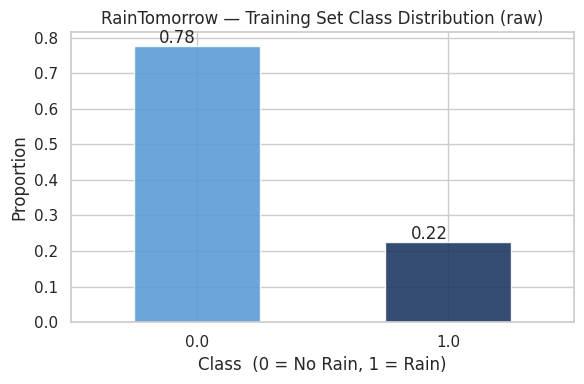

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
y_train.value_counts(normalize=True).plot(
    kind='bar', color=['#5B9BD5', '#1F3864'], alpha=0.9, rot=0, ax=ax
)
ax.set_title('RainTomorrow — Training Set Class Distribution (raw)')
ax.set_xlabel('Class  (0 = No Rain, 1 = Rain)')
ax.set_ylabel('Proportion')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + 0.1, p.get_height() + 0.01))
plt.tight_layout()
plt.show()

### 5.2 Missing Value Analysis

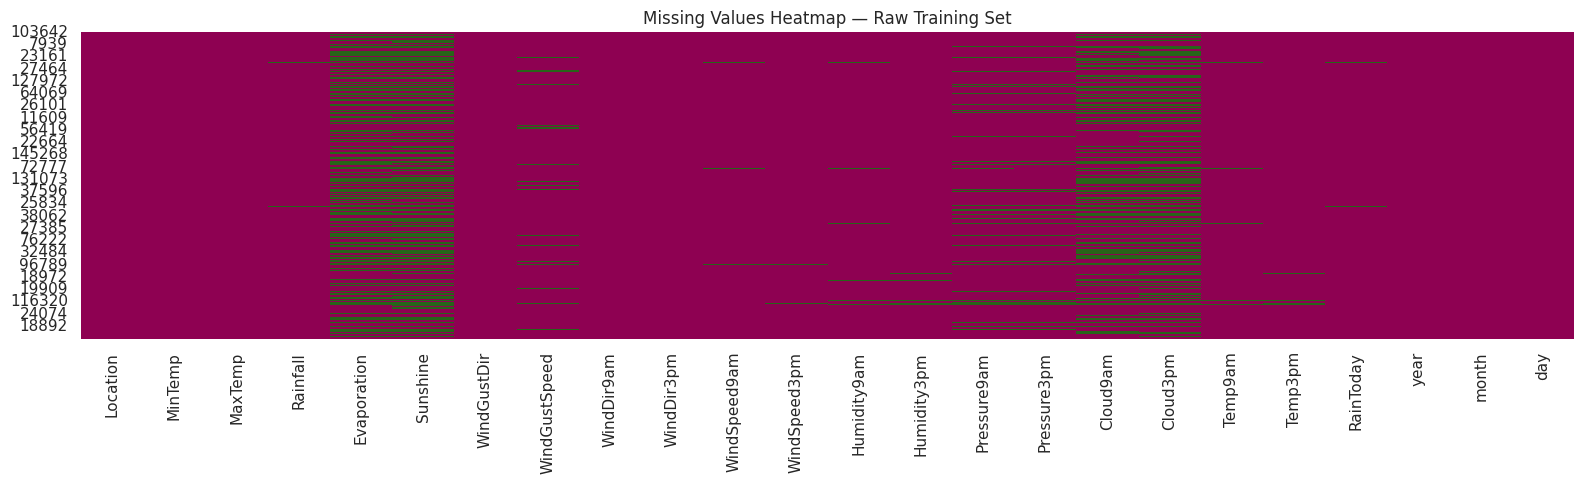

,Missing Count,Missing %
Sunshine,54344,47.773265
Evaporation,48695,42.807286
Cloud3pm,45669,40.147160
Cloud9am,42877,37.692740
Pressure9am,11287,9.922288
Pressure3pm,11262,9.900311
WindGustSpeed,7440,6.540429
Humidity3pm,2897,2.546724
Temp3pm,2203,1.936635
WindSpeed3pm,2130,1.872462


In [ ]:
# Heatmap
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(X_train.isnull(), cbar=False, cmap='PiYG', ax=ax)
ax.set_title('Missing Values Heatmap — Raw Training Set')
plt.tight_layout()
plt.show()

# Summary table
total   = X_train.isnull().sum().sort_values(ascending=False)
percent = (X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False)
missing_df = pd.concat([total, percent], axis=1, keys=['Missing Count', 'Missing %'])
missing_df[missing_df['Missing Count'] > 0]

### 5.3 Feature Distributions

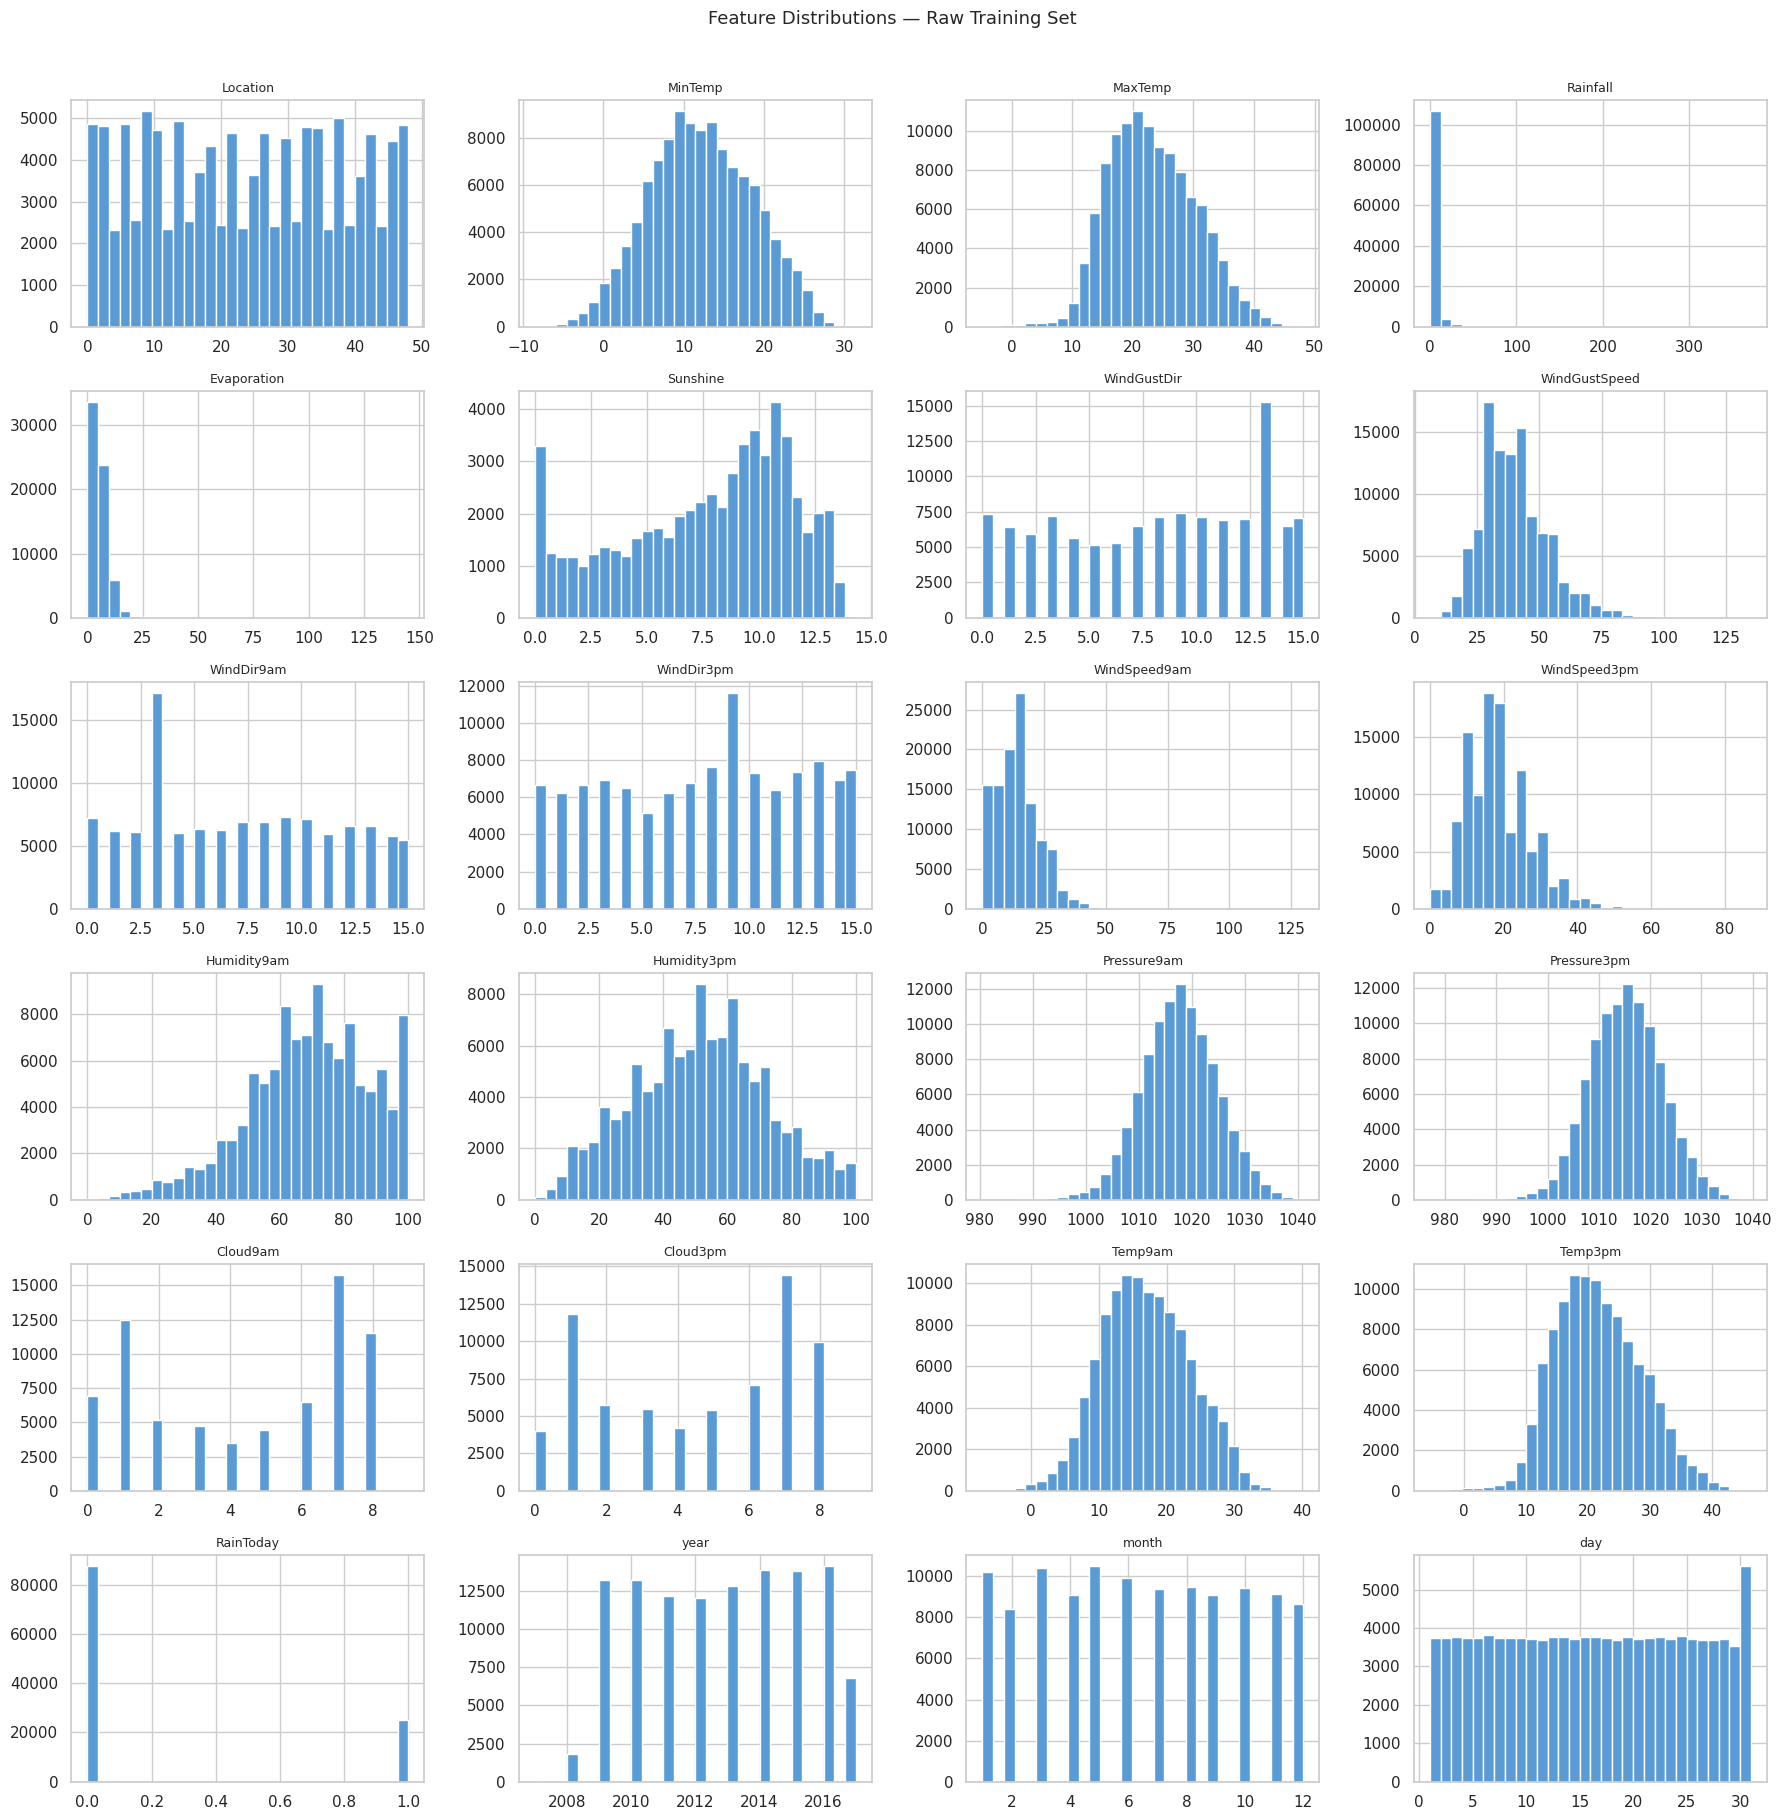

In [ ]:
# Distribution of key numeric features
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    X_train[col].dropna().hist(bins=30, ax=axes[i], color='#5B9BD5', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions — Raw Training Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Outlier Visualization (Boxplots)

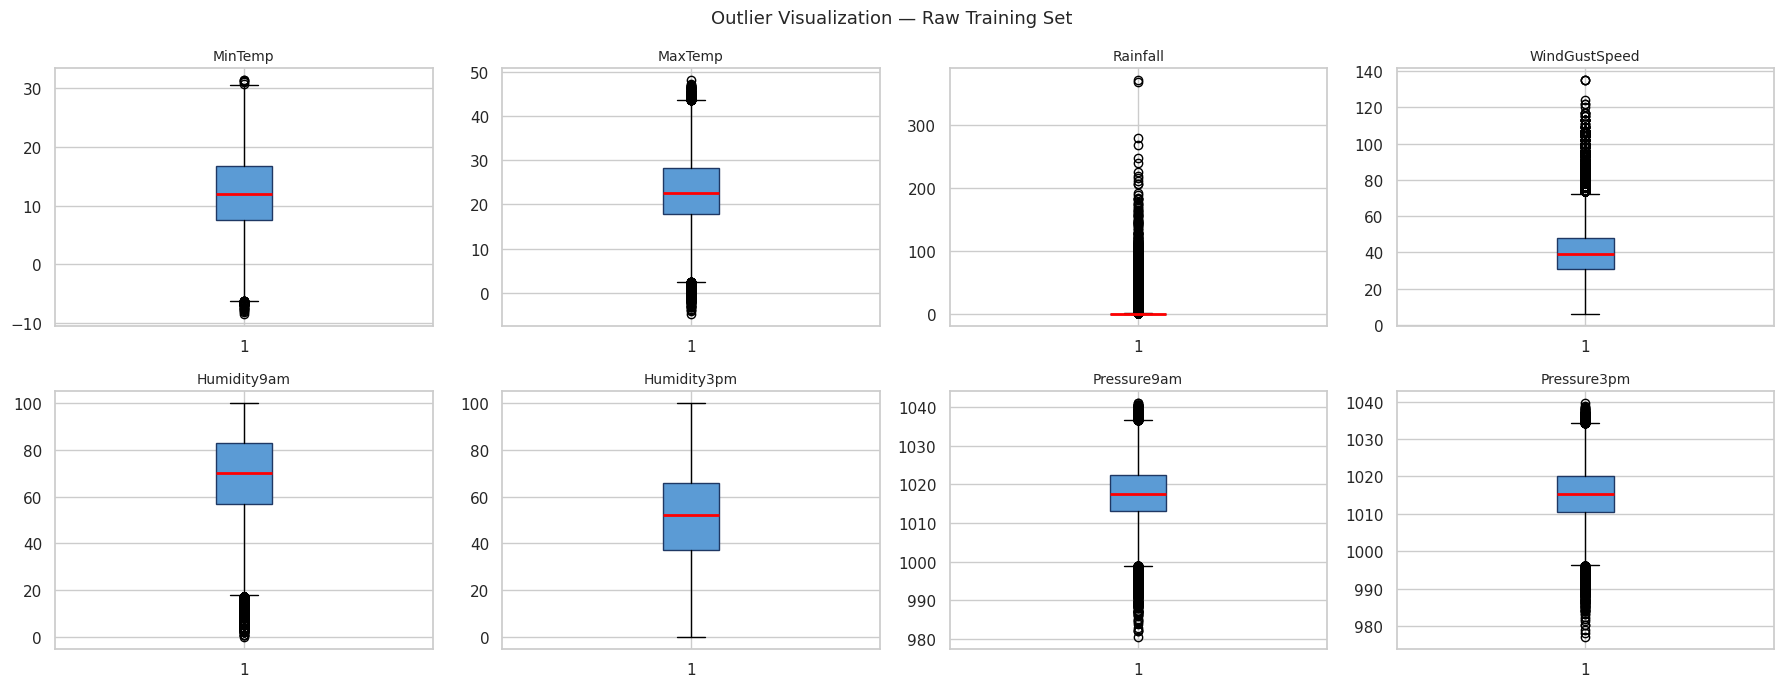

In [ ]:
key_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    axes[i].boxplot(X_train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#5B9BD5', color='#1F3864'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)

fig.suptitle('Outlier Visualization — Raw Training Set', fontsize=13)
plt.tight_layout()
plt.show()

### 5.5 Correlation Heatmap (Raw Training Set)

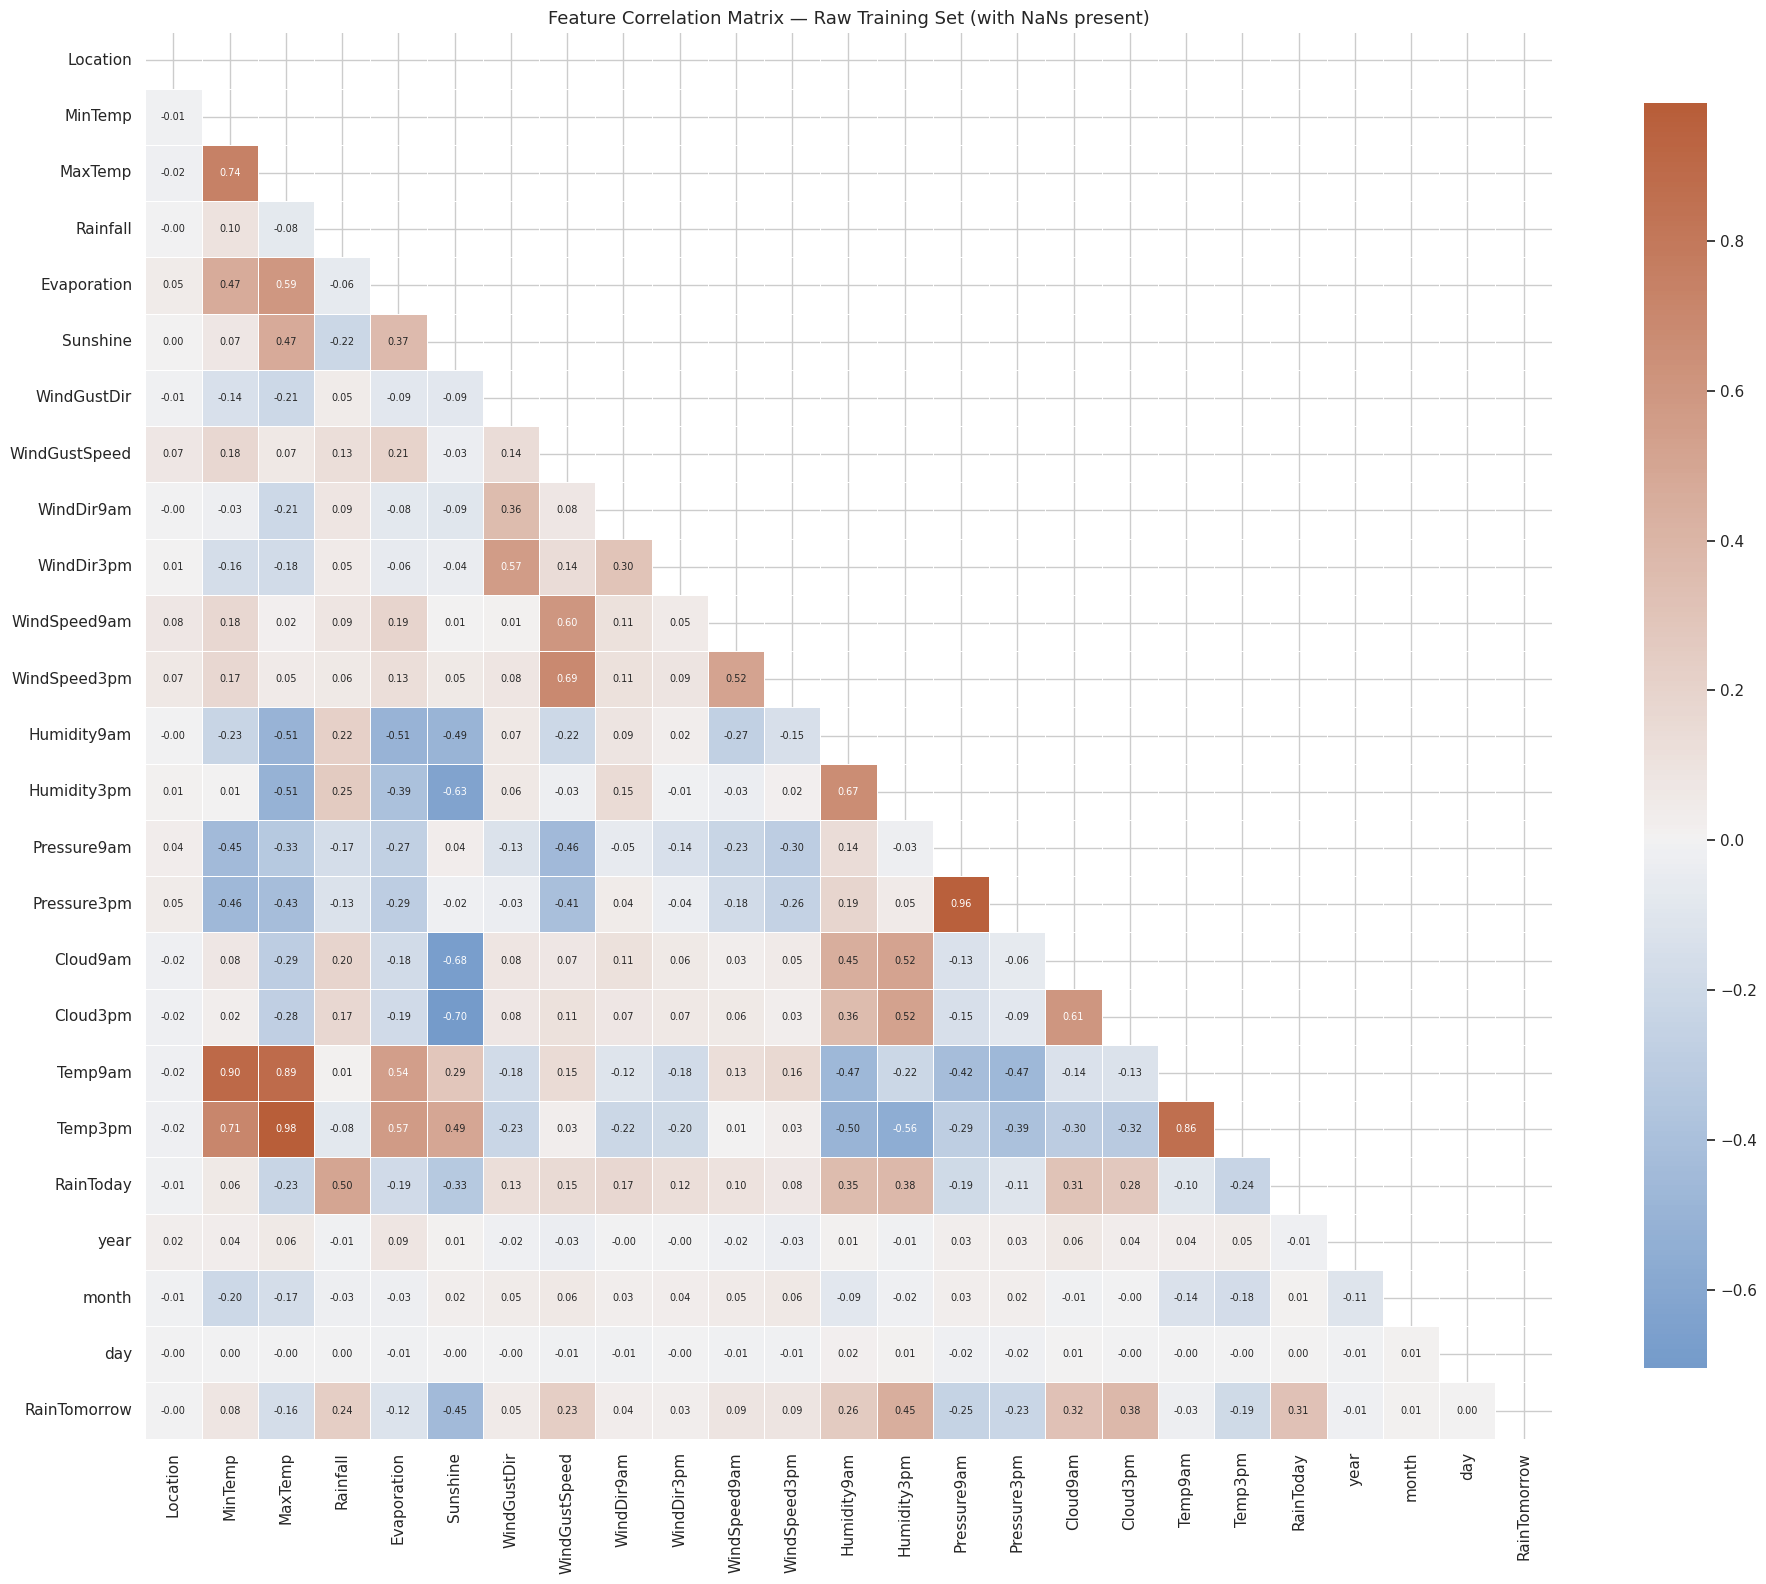

In [ ]:
# Combine X_train and y_train for correlation with target
train_eda = X_train.copy()
train_eda['RainTomorrow'] = y_train.values

corr = train_eda.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr, mask=mask,
    cmap=sns.diverging_palette(250, 25, as_cmap=True),
    center=0, square=True, annot=True, fmt='.2f',
    linewidths=0.5, cbar_kws={'shrink': 0.9},
    ax=ax, annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Matrix — Raw Training Set (with NaNs present)', fontsize=13)
plt.tight_layout()
plt.show()

### 5.6 Pairplot — Key Weather Variables

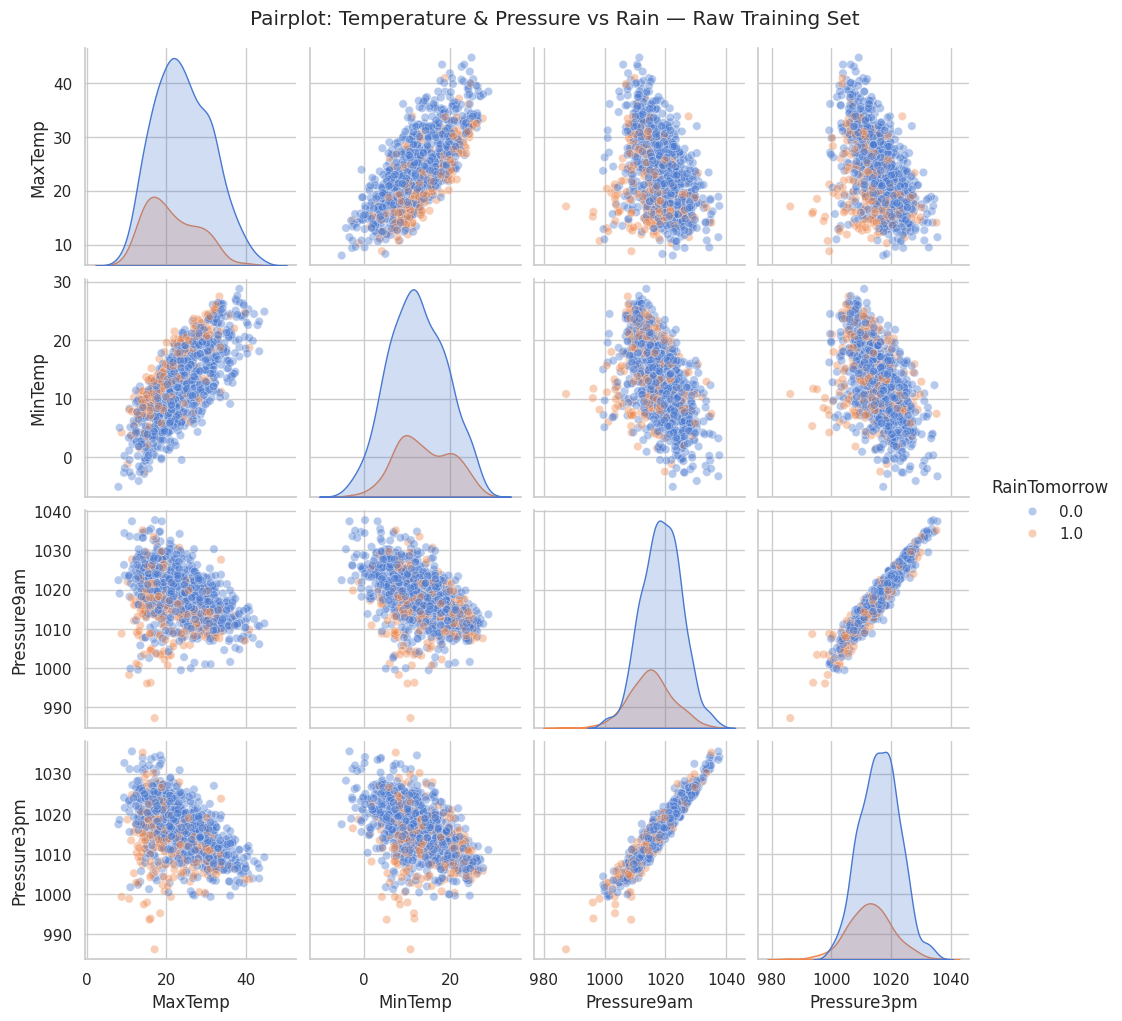

In [ ]:
pair_cols = ['MaxTemp', 'MinTemp', 'Pressure9am', 'Pressure3pm', 'RainTomorrow']
pair_df   = train_eda[pair_cols].dropna().sample(1000, random_state=42)

sns.pairplot(
    pair_df, hue='RainTomorrow',
    plot_kws={'alpha': 0.4}, diag_kind='kde'
)
plt.suptitle('Pairplot: Temperature & Pressure vs Rain — Raw Training Set', y=1.02)
plt.show()

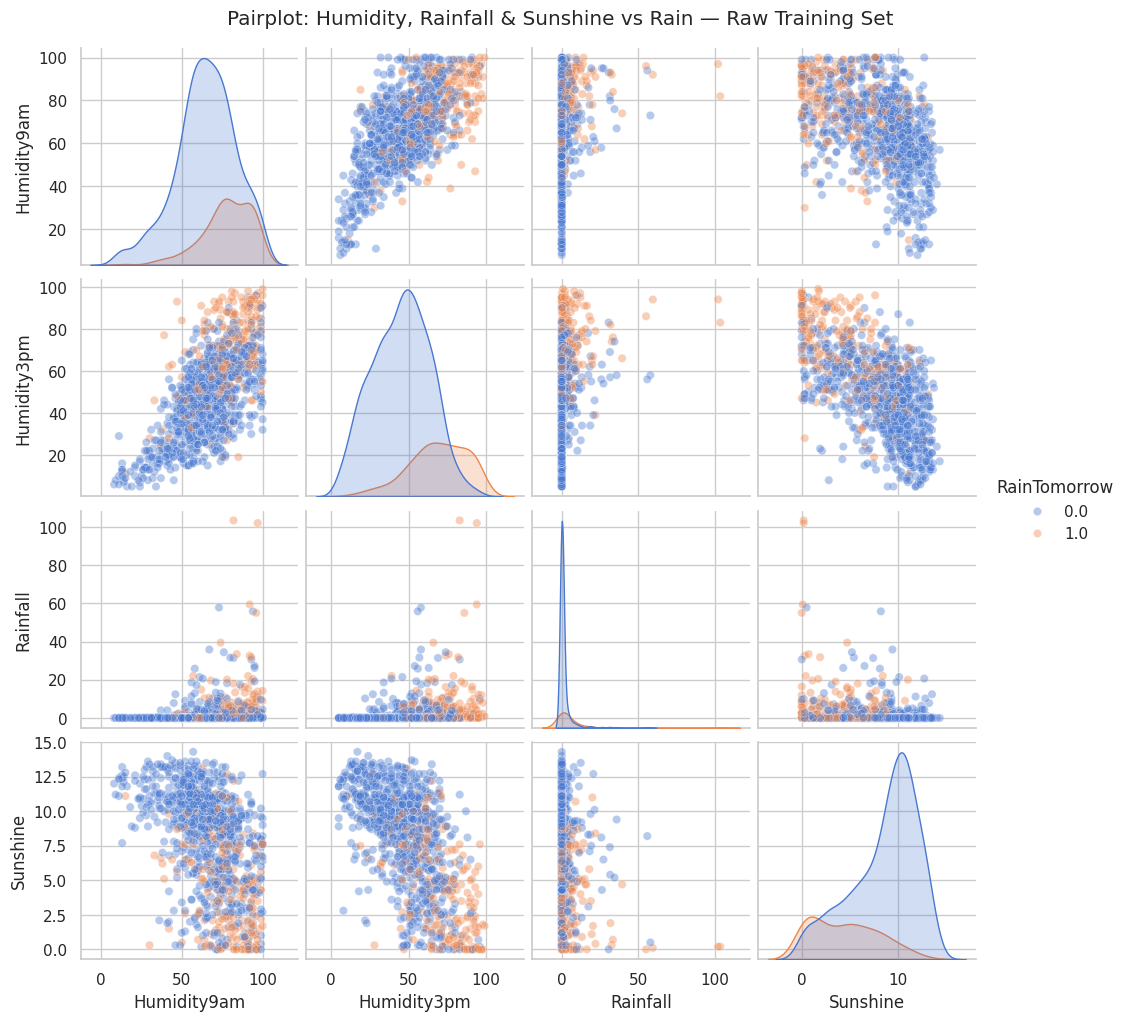

In [ ]:
pair_cols2 = ['Humidity9am', 'Humidity3pm', 'Rainfall', 'Sunshine', 'RainTomorrow']
pair_df2   = train_eda[pair_cols2].dropna().sample(1000, random_state=42)

sns.pairplot(
    pair_df2, hue='RainTomorrow',
    plot_kws={'alpha': 0.4}, diag_kind='kde'
)
plt.suptitle('Pairplot: Humidity, Rainfall & Sunshine vs Rain — Raw Training Set', y=1.02)
plt.show()

### 5.7 Target Correlation (Which features correlate most with RainTomorrow?)

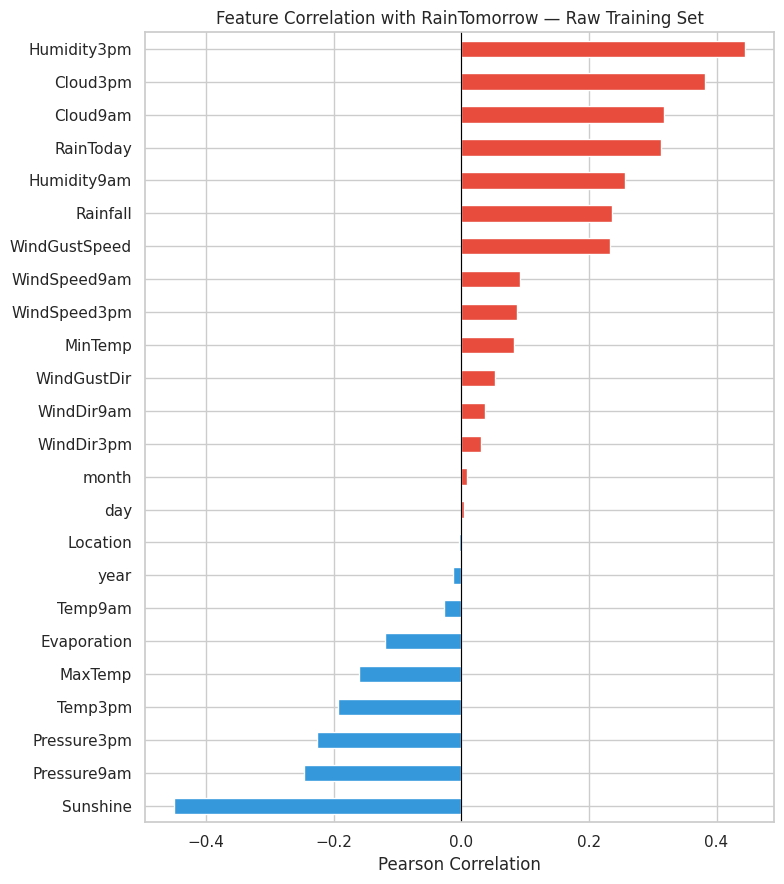

In [ ]:
target_corr = train_eda.corr()['RainTomorrow'].drop('RainTomorrow').sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr]
target_corr.plot(kind='barh', color=colors, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with RainTomorrow — Raw Training Set')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

---
## 6. Feature Engineering  (train only — no leakage)

All fitting steps below use **only training data**.

### 6.1 MICE Imputation  (fit on train → transform both)

In [ ]:
mice_imputer = IterativeImputer(random_state=42, max_iter=10)
mice_imputer.fit(X_train)

X_train_imp = pd.DataFrame(
    mice_imputer.transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_imp = pd.DataFrame(
    mice_imputer.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print(f'Missing in X_train after imputation : {X_train_imp.isnull().sum().sum()}')
print(f'Missing in X_test  after imputation : {X_test_imp.isnull().sum().sum()}')

Missing in X_train after imputation : 0
Missing in X_test  after imputation : 0


### 6.2 IQR Outlier Removal  (train only — boundaries computed on train)

In [ ]:
Q1  = X_train_imp.quantile(0.25)
Q3  = X_train_imp.quantile(0.75)
IQR = Q3 - Q1

outlier_mask  = ((X_train_imp < (Q1 - 1.5 * IQR)) | (X_train_imp > (Q3 + 1.5 * IQR))).any(axis=1)
X_train_clean = X_train_imp[~outlier_mask]
y_train_clean = y_train[~outlier_mask]

print(f'Rows removed as outliers          : {outlier_mask.sum():,}')
print(f'Training rows after outlier removal: {X_train_clean.shape[0]:,}')

Rows removed as outliers          : 33,014
Training rows after outlier removal: 80,740


### 6.3 SMOTE  (train only)

Creates synthetic minority samples by interpolating between real neighbours.  
Applied **after** imputation and outlier removal so no NaNs exist during resampling.

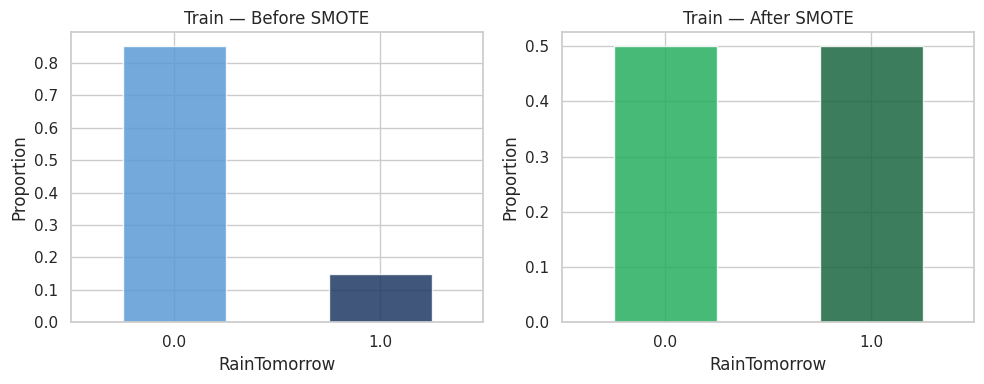

Before SMOTE : {0.0: 68798, 1.0: 11942}
After  SMOTE : {0.0: 68798, 1.0: 68798}


In [ ]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_clean, y_train_clean)

X_train_sm = pd.DataFrame(X_train_sm, columns=X_train_clean.columns)
y_train_sm = pd.Series(y_train_sm, name='RainTomorrow')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train_clean.value_counts(normalize=True).plot(
    kind='bar', ax=axes[0], color=['#5B9BD5', '#1F3864'], rot=0, alpha=0.85
)
axes[0].set_title('Train — Before SMOTE')
axes[0].set_ylabel('Proportion')

y_train_sm.value_counts(normalize=True).plot(
    kind='bar', ax=axes[1], color=['#27ae60', '#1a6640'], rot=0, alpha=0.85
)
axes[1].set_title('Train — After SMOTE')
axes[1].set_ylabel('Proportion')
plt.tight_layout()
plt.show()

print(f'Before SMOTE : {y_train_clean.value_counts().to_dict()}')
print(f'After  SMOTE : {y_train_sm.value_counts().to_dict()}')

### 6.4 Feature Scaling  (fit on train → transform both)

In [ ]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test_imp)   # transform only — no fit

print(f'Final train shape : {X_train_sc.shape}')
print(f'Final test  shape : {X_test_sc.shape}')

Final train shape : (137596, 24)
Final test  shape : (28439, 24)


---
## 7. Feature Selection  (on processed train only)

Done after preprocessing so the importance scores reflect clean, imputed data.

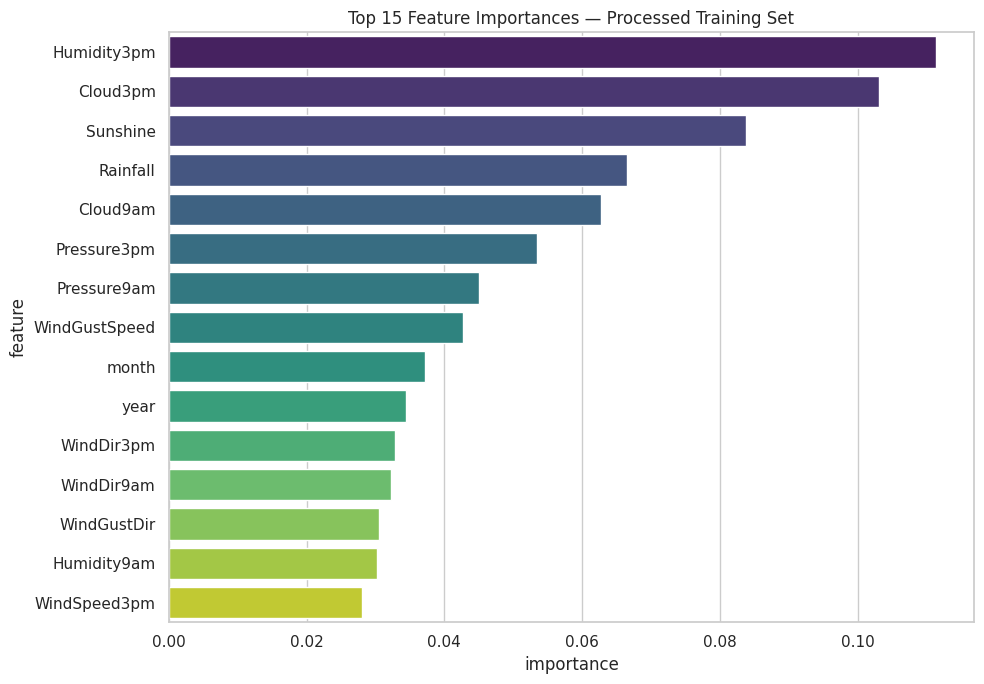

In [ ]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
rf_selector.fit(X_train_sc, y_train_sm)

feat_imp_df = pd.DataFrame({
    'feature': X_train_sm.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=feat_imp_df.head(15), x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Top 15 Feature Importances — Processed Training Set')
plt.tight_layout()
plt.show()

---
## 8. Helper Functions

In [ ]:
def plot_roc_curve(fper, tper, model_name='Model'):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fper, tper, color='darkorange', lw=2, label='ROC Curve')
    ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {model_name}')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name='Model'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_tr, y_tr, X_te, y_te,
                   model_name='Model', log_mlflow=True):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    roc_auc = roc_auc_score(y_te, probs)
    kappa = cohen_kappa_score(y_te, y_pred)

    if log_mlflow:
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_params(model.get_params())
            mlflow.log_metrics({
                'accuracy': acc,
                'roc_auc': roc_auc,
                'cohen_kappa': kappa,
                'train_time_s': elapsed
            })
            mlflow.sklearn.log_model(model, artifact_path=model_name)

    print(f'[{model_name}] Accuracy={acc:.4f} ROC-AUC={roc_auc:.4f} Kappa={kappa:.4f}  Time={elapsed:.2f}s')
    print(classification_report(y_te, y_pred, digits=4))

    fper, tper, _ = roc_curve(y_te, probs)
    plot_roc_curve(fper, tper, model_name)
    plot_confusion_matrix(y_te, y_pred, model_name)

    return model, acc, roc_auc, kappa, elapsed

---
## 9. MLflow Experiment Setup

In [ ]:
mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment('Rainfall_Weather_Forecasting_v3')

parent_run = mlflow.start_run(run_name='All_Models_SMOTE_Optuna')
mlflow.set_tags({
    'smote':        'True',
    'imputer':      'MICE',
    'tuning':       'Optuna',
    'leakage_free': 'True',
    'eda_position': 'after_split_before_feature_engineering',
    'dataset':      'Australian Rainfall 10y'
})

2026/02/21 11:33:40 INFO mlflow.tracking.fluent: Experiment with name 'Rainfall_Weather_Forecasting_v3' does not exist. Creating a new experiment.


---
## 10. Baseline Models

### 10.1 Logistic Regression

2026/02/21 11:34:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/21 11:34:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Logistic_Regression] Accuracy=0.7183 ROC-AUC=0.8520 Kappa=0.4032  Time=6.33s
              precision    recall  f1-score   support

         0.0     0.9487    0.6733    0.7876     22064
         1.0     0.4359    0.8739    0.5817      6375

    accuracy                         0.7183     28439
   macro avg     0.6923    0.7736    0.6847     28439
weighted avg     0.8337    0.7183    0.7415     28439



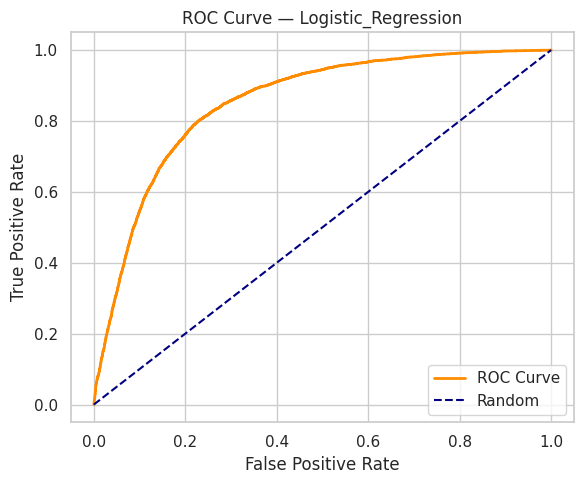

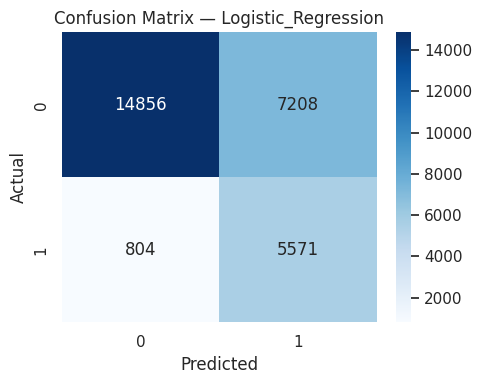

In [ ]:
model_lr, acc_lr, roc_lr, kap_lr, tt_lr = evaluate_model(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    X_train_sc, y_train_sm, X_test_sc, y_test,
    model_name='Logistic_Regression'
)

### 10.2 Decision Tree

2026/02/21 11:35:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/21 11:35:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Decision_Tree] Accuracy=0.7310 ROC-AUC=0.7168 Kappa=0.3419  Time=1.07s
              precision    recall  f1-score   support

         0.0     0.8808    0.7556    0.8134     22064
         1.0     0.4330    0.6461    0.5185      6375

    accuracy                         0.7310     28439
   macro avg     0.6569    0.7008    0.6660     28439
weighted avg     0.7804    0.7310    0.7473     28439



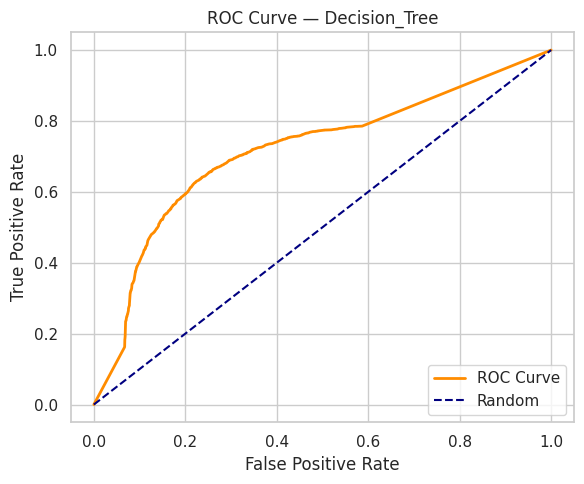

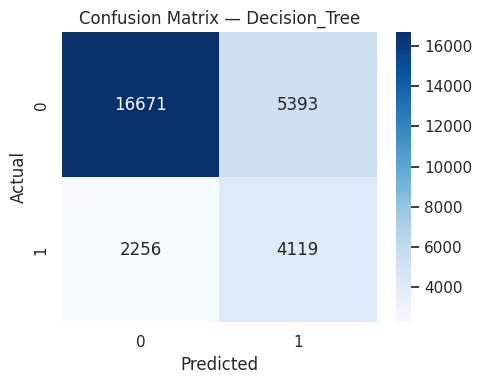

In [ ]:
model_dt, acc_dt, roc_dt, kap_dt, tt_dt = evaluate_model(
    DecisionTreeClassifier(max_depth=16, max_features='sqrt', random_state=42),
    X_train_sc, y_train_sm, X_test_sc, y_test,
    model_name='Decision_Tree'
)

### 10.3 Neural Network

2026/02/21 11:37:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/21 11:37:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Neural_Network] Accuracy=0.7417 ROC-AUC=0.5344 Kappa=0.2286  Time=115.56s
              precision    recall  f1-score   support

         0.0     0.8237    0.8487    0.8360     22064
         1.0     0.4149    0.3715    0.3920      6375

    accuracy                         0.7417     28439
   macro avg     0.6193    0.6101    0.6140     28439
weighted avg     0.7321    0.7417    0.7365     28439



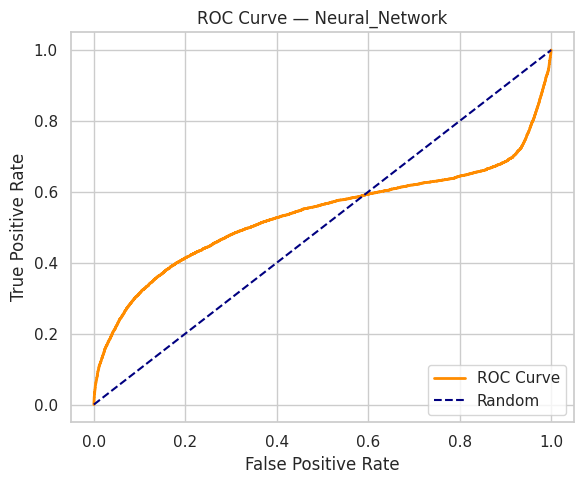

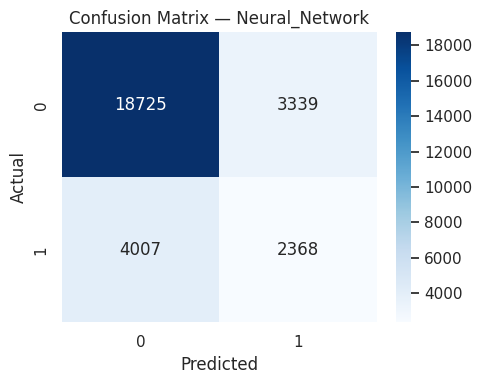

In [ ]:
model_nn, acc_nn, roc_nn, kap_nn, tt_nn = evaluate_model(
    MLPClassifier(
        hidden_layer_sizes=(64, 64, 32), activation='relu',
        solver='adam', max_iter=500, random_state=42, early_stopping=True
    ),
    X_train_sc, y_train_sm, X_test_sc, y_test,
    model_name='Neural_Network'
)

### 10.4 Random Forest

2026/02/21 11:39:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/21 11:39:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Random_Forest] Accuracy=0.8172 ROC-AUC=0.8741 Kappa=0.5191  Time=106.28s
              precision    recall  f1-score   support

         0.0     0.9135    0.8443    0.8775     22064
         1.0     0.5730    0.7231    0.6394      6375

    accuracy                         0.8172     28439
   macro avg     0.7432    0.7837    0.7585     28439
weighted avg     0.8371    0.8172    0.8241     28439



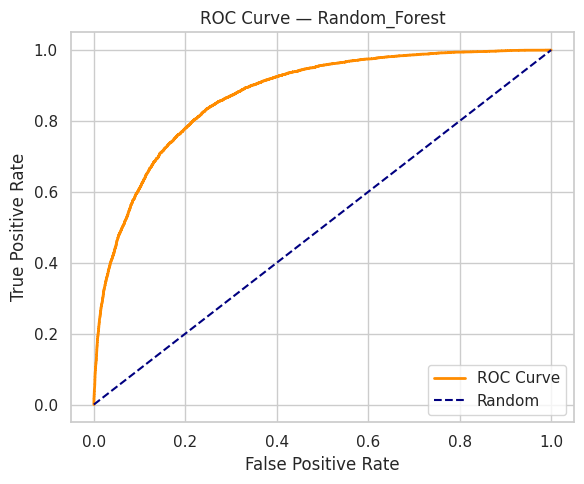

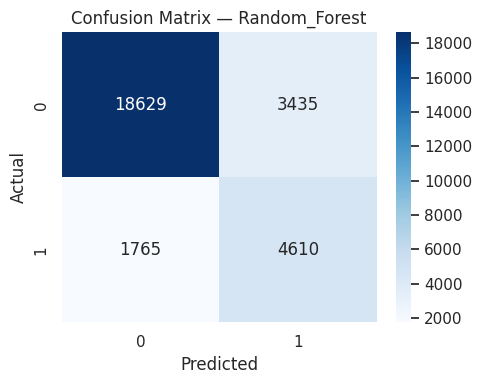

In [ ]:
model_rf, acc_rf, roc_rf, kap_rf, tt_rf = evaluate_model(
    RandomForestClassifier(
        max_depth=16, n_estimators=100, random_state=42, n_jobs=-1
    ),
    X_train_sc, y_train_sm, X_test_sc, y_test,
    model_name='Random_Forest'
)

### 10.5 LightGBM

2026/02/21 11:39:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/21 11:39:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LightGBM] Accuracy=0.8546 ROC-AUC=0.8908 Kappa=0.5380  Time=17.52s
              precision    recall  f1-score   support

         0.0     0.8772    0.9448    0.9098     22064
         1.0     0.7396    0.5421    0.6256      6375

    accuracy                         0.8546     28439
   macro avg     0.8084    0.7435    0.7677     28439
weighted avg     0.8463    0.8546    0.8461     28439



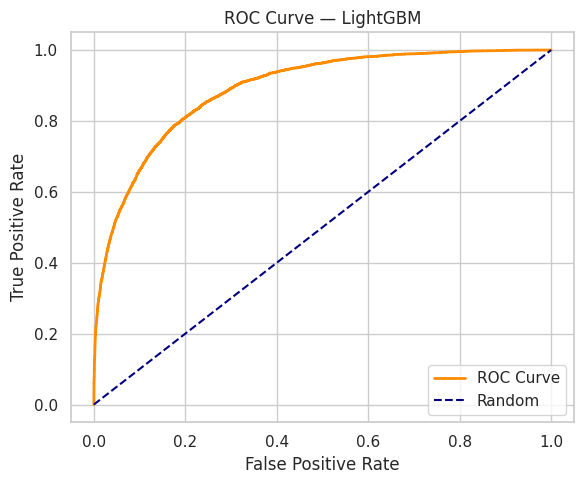

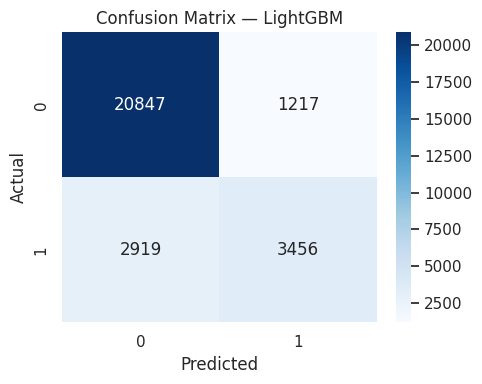

In [ ]:
model_lgb, acc_lgb, roc_lgb, kap_lgb, tt_lgb = evaluate_model(
    lgb.LGBMClassifier(
        colsample_bytree=0.95, max_depth=16, min_split_gain=0.1,
        n_estimators=200, num_leaves=50, reg_alpha=1.2, reg_lambda=1.2,
        subsample=0.95, subsample_freq=20, verbose=-1, random_state=42
    ),
    X_train_sc, y_train_sm, X_test_sc, y_test,
    model_name='LightGBM'
)

### 10.6 XGBoost

2026/02/21 11:41:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/21 11:41:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[XGBoost] Accuracy=0.8572 ROC-AUC=0.8912 Kappa=0.5505  Time=77.35s
              precision    recall  f1-score   support

         0.0     0.8811    0.9432    0.9111     22064
         1.0     0.7400    0.5595    0.6372      6375

    accuracy                         0.8572     28439
   macro avg     0.8106    0.7514    0.7742     28439
weighted avg     0.8495    0.8572    0.8497     28439



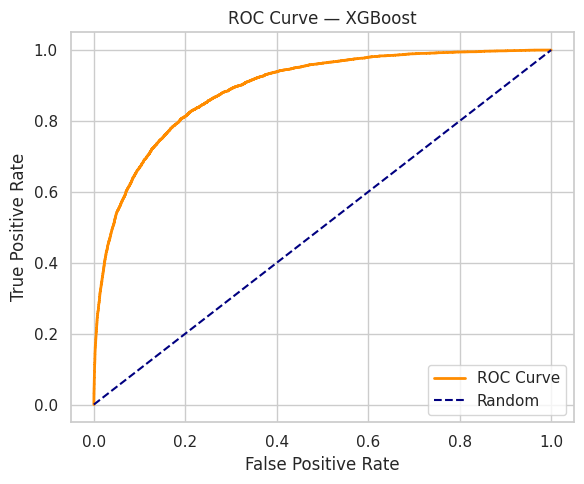

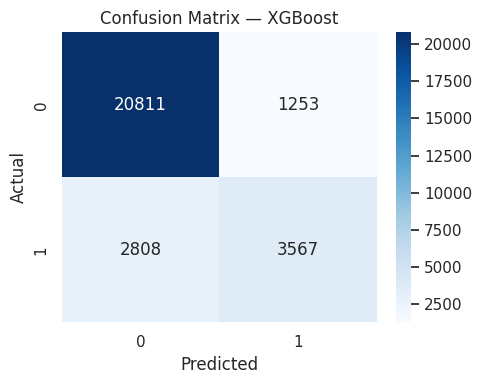

In [ ]:
model_xgb, acc_xgb, roc_xgb, kap_xgb, tt_xgb = evaluate_model(
    xgb.XGBClassifier(
        n_estimators=500, max_depth=16, eval_metric='logloss',
        random_state=42, verbosity=0, n_jobs=-1
    ),
    X_train_sc, y_train_sm, X_test_sc, y_test,
    model_name='XGBoost'
)

---
## 11. Optuna Hyperparameter Tuning

All cross-validation runs entirely inside the training fold — test set is never touched.

In [ ]:
CV_FOLDS = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 11.1 Random Forest Tuning

In [ ]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 24),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42, 'n_jobs': -1
    }
    return cross_val_score(
        RandomForestClassifier(**params),
        X_train_sc, y_train_sm, cv=CV_FOLDS, scoring='roc_auc', n_jobs=-1
    ).mean()


study_rf = optuna.create_study(direction='maximize', study_name='RF_Tuning',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(rf_objective, n_trials=40, show_progress_bar=True)

best_rf_params = {**study_rf.best_params, 'random_state': 42, 'n_jobs': -1}
print(f'Best RF CV ROC-AUC : {study_rf.best_value:.4f}')
print('Best params :', best_rf_params)

  0%|          | 0/40 [00:00<?, ?it/s]

[W 2026-02-21 11:48:31,471] Trial 0 failed with parameters: {'n_estimators': 250, 'max_depth': 23, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'sqrt'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-1392997596.py", line 10, in rf_objective
    return cross_val_score(
           ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 684, in cross_val_score
    cv_results = cross_validate(
                 ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216

KeyboardInterrupt: 

In [ ]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study_rf)
plt.title('RF — Optuna Optimization History'); plt.tight_layout(); plt.show()

fig = optuna.visualization.matplotlib.plot_param_importances(study_rf)
plt.title('RF — Hyperparameter Importances'); plt.tight_layout(); plt.show()

In [ ]:
model_rf_t, acc_rf_t, roc_rf_t, kap_rf_t, tt_rf_t = evaluate_model(
    RandomForestClassifier(**best_rf_params),
    X_train_sc, y_train_sm, X_test_sc, y_test,
    model_name='Random_Forest_Tuned'
)

### 11.2 LightGBM Tuning

In [ ]:
def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 700, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 24),
        'num_leaves': trial.suggest_int('num_leaves', 20, 120),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
        'verbose': -1, 'random_state': 42
    }
    return cross_val_score(
        lgb.LGBMClassifier(**params),
        X_train_sc, y_train_sm, cv=CV_FOLDS, scoring='roc_auc', n_jobs=-1
    ).mean()


study_lgb = optuna.create_study(direction='maximize', study_name='LGB_Tuning',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_objective, n_trials=40, show_progress_bar=True)

best_lgb_params = {**study_lgb.best_params, 'verbose': -1, 'random_state': 42}
print(f'Best LGB CV ROC-AUC : {study_lgb.best_value:.4f}')
print('Best params :', best_lgb_params)

In [ ]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study_lgb)
plt.title('LGB — Optuna Optimization History'); plt.tight_layout(); plt.show()

fig = optuna.visualization.matplotlib.plot_param_importances(study_lgb)
plt.title('LGB — Hyperparameter Importances'); plt.tight_layout(); plt.show()

In [ ]:
model_lgb_t, acc_lgb_t, roc_lgb_t, kap_lgb_t, tt_lgb_t = evaluate_model(
    lgb.LGBMClassifier(**best_lgb_params),
    X_train_sc, y_train_sm, X_test_sc, y_test,
    model_name='LightGBM_Tuned'
)

### 11.3 XGBoost Tuning

In [ ]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 700, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'eval_metric': 'logloss', 'verbosity': 0,
        'random_state': 42, 'n_jobs': -1
    }
    return cross_val_score(
        xgb.XGBClassifier(**params),
        X_train_sc, y_train_sm, cv=CV_FOLDS, scoring='roc_auc', n_jobs=-1
    ).mean()


study_xgb = optuna.create_study(direction='maximize', study_name='XGB_Tuning',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

best_xgb_params = {
    **study_xgb.best_params,
    'eval_metric': 'logloss', 'verbosity': 0,
    'random_state': 42, 'n_jobs': -1
}
print(f'Best XGB CV ROC-AUC : {study_xgb.best_value:.4f}')
print('Best params :', best_xgb_params)

In [ ]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study_xgb)
plt.title('XGB — Optuna Optimization History'); plt.tight_layout(); plt.show()

fig = optuna.visualization.matplotlib.plot_param_importances(study_xgb)
plt.title('XGB — Hyperparameter Importances'); plt.tight_layout(); plt.show()

In [ ]:
model_xgb_t, acc_xgb_t, roc_xgb_t, kap_xgb_t, tt_xgb_t = evaluate_model(
    xgb.XGBClassifier(**best_xgb_params),
    X_train_sc, y_train_sm, X_test_sc, y_test,
    model_name='XGBoost_Tuned'
)

### 11.4 Decision Tree Tuning

In [ ]:
def dt_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 28),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42
    }
    return cross_val_score(
        DecisionTreeClassifier(**params),
        X_train_sc, y_train_sm, cv=CV_FOLDS, scoring='roc_auc', n_jobs=-1
    ).mean()


study_dt = optuna.create_study(direction='maximize', study_name='DT_Tuning',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_dt.optimize(dt_objective, n_trials=40, show_progress_bar=True)

best_dt_params = {**study_dt.best_params, 'random_state': 42}
print(f'Best DT CV ROC-AUC : {study_dt.best_value:.4f}')
print('Best params :', best_dt_params)

In [ ]:
model_dt_t, acc_dt_t, roc_dt_t, kap_dt_t, tt_dt_t = evaluate_model(
    DecisionTreeClassifier(**best_dt_params),
    X_train_sc, y_train_sm, X_test_sc, y_test,
    model_name='Decision_Tree_Tuned'
)

---
## 12. Full Model Comparison

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression','Decision Tree','Neural Network',
        'Random Forest','LightGBM','XGBoost',
        'Random Forest Tuned','LightGBM Tuned','XGBoost Tuned',
        'Decision Tree Tuned'
    ],
    'Accuracy': [acc_lr, acc_dt, acc_nn, acc_rf, acc_lgb, acc_xgb,
                    acc_rf_t, acc_lgb_t, acc_xgb_t, acc_dt_t],
    'ROC_AUC': [roc_lr, roc_dt, roc_nn, roc_rf, roc_lgb, roc_xgb,
                    roc_rf_t, roc_lgb_t, roc_xgb_t, roc_dt_t],
    'Cohen_Kappa':[kap_lr, kap_dt,  kap_nn, kap_rf, kap_lgb, kap_xgb,
                    kap_rf_t, kap_lgb_t, kap_xgb_t, kap_dt_t],
    'Time_sec': [tt_lr, tt_dt, tt_nn, tt_rf, tt_lgb, tt_xgb,
                    tt_rf_t, tt_lgb_t, tt_xgb_t, tt_dt_t],
    'Tuned': ['No'] * 6 + ['Yes'] * 4
}).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

results

In [ ]:
from matplotlib.patches import Patch
palette = ['#27ae60' if t == 'Yes' else '#3498db' for t in results['Tuned']]
legend_handles = [Patch(color='#3498db', label='Baseline'), Patch(color='#27ae60', label='Tuned')]

# Accuracy vs Time
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.set_title('Model Comparison: Accuracy vs Training Time', fontsize=13)
ax1.bar(results['Model'], results['Time_sec'], color=palette, alpha=0.8)
ax1.set_ylabel('Time (seconds)', color='tab:green')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend(handles=legend_handles, loc='upper left')
ax2 = ax1.twinx()
ax2.plot(results['Model'], results['Accuracy'], color='tab:red', marker='o', lw=2)
ax2.set_ylabel('Accuracy', color='tab:red')
plt.tight_layout()
plt.show()

In [ ]:
# ROC-AUC vs Cohen Kappa
fig, ax3 = plt.subplots(figsize=(14, 6))
ax3.set_title('Model Comparison: ROC-AUC vs Cohen Kappa', fontsize=13)
ax3.bar(results['Model'], results['ROC_AUC'], color=palette, alpha=0.8)
ax3.set_ylabel('ROC-AUC', color='tab:blue')
ax3.set_ylim(0.65, 1.0)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)
ax3.legend(handles=legend_handles, loc='lower right')
ax4 = ax3.twinx()
ax4.plot(results['Model'], results['Cohen_Kappa'], color='tab:red', marker='s', lw=2)
ax4.set_ylabel("Cohen's Kappa", color='tab:red')
plt.tight_layout()
plt.show()

---
## 13. MLflow — Close Parent Run & Final Summary

In [ ]:
best_row = results.iloc[0]

with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.log_metrics({
        'best_accuracy': best_row['Accuracy'],
        'best_roc_auc': best_row['ROC_AUC'],
        'best_cohen_kappa': best_row['Cohen_Kappa'],
    })
    mlflow.set_tag('best_model', best_row['Model'])

mlflow.end_run()

print('Best Model :', best_row['Model'])
print(f'Accuracy : {best_row["Accuracy"]:.4f}')
print(f'ROC-AUC : {best_row["ROC_AUC"]:.4f}')
print(f'Cohen Kappa : {best_row["Cohen_Kappa"]:.4f}')
print('\nMLflow run complete. Launch with:  mlflow ui')

---
## 14. Final Results Table

In [ ]:
results.style \
    .background_gradient(subset=['Accuracy', 'ROC_AUC', 'Cohen_Kappa'], cmap='YlGn') \
    .background_gradient(subset=['Time_sec'], cmap='YlOrRd') \
    .format({
        'Accuracy': '{:.4f}',
        'ROC_AUC': '{:.4f}',
        'Cohen_Kappa': '{:.4f}',
        'Time_sec': '{:.2f}s'
    })

In [ ]:
!mlflow ui